# Weeks 3+ — Working with the full release (~79M rows) without downloading 79M rows

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/notebooks/03_working_with_the_full_release.ipynb?flush_cache=true)

Notebooks 01–02 used the small starter CSV that ships with this repo. Your lane and capstone work
run on the **full pseudonymized warehouse release**: ~17 months of daily search performance for
~70 clients, plus a query-level table. It is hosted as Parquet on Hugging Face, and the trick of
this notebook is that you **never download or load the whole thing** — DuckDB reads only the
columns and partitions your SQL touches.

By the end you will have:
1. Connected DuckDB to the hosted release and listed every table.
2. Pulled a **feature table you designed** (aggregates per content item) into pandas.
3. Trained a quick scikit-learn model on features you built from 79M rows — on a free Colab CPU.

**Before you start (one-time, ~2 minutes):**
1. Create a free [Hugging Face account](https://huggingface.co/join).
2. Open the dataset page ([`FlyRank/internship-warehouse`](https://huggingface.co/datasets/FlyRank/internship-warehouse)) and **request access** (instant after you accept the data-use terms). **Accept the terms in your browser first — the token below 401s until access is granted (usually instant).**
3. Create a **read** token at [Settings → Access Tokens](https://huggingface.co/settings/tokens). **Never paste the token into a code cell** — your repo is public; use the `getpass` prompt below (or Colab's 🔑 Secrets panel).


In [ ]:
%pip -q install duckdb huggingface_hub


In [1]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


## 1. Connect DuckDB to the release

DuckDB speaks `hf://` natively. The secret below authenticates every query; after that the
release behaves like a set of local tables.


In [2]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


That count over the daily fact touched **Parquet metadata, not data** — it finished in seconds
even though the table has ~79M rows. That is the whole workflow: push the heavy lifting into
DuckDB SQL, bring only small results into pandas.

## 2. Know your panel before you model it

History depth **differs per client** (an *unbalanced panel*). `dim_clients` tells you exactly
what each client has — check it before designing any time window.


In [3]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


## 3. Build features with SQL, not with RAM

The pattern for every lane: **aggregate per content item inside DuckDB**, then hand the small
result to pandas/sklearn. Here: momentum features from the last 60 days of the panel.

**This is the heaviest cell in the notebook — expect 2–6 minutes on Colab.** It downloads ~2 months of column data over the network (RAM stays tiny; that's the point). If it runs past ~10 minutes or errors with `HTTP 429`, re-run this section against `TABLES['fact_daily_sample']` and save the full table for your final pass.


In [4]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 60 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

111,247 content items with enough history


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483


## 4. Add query-level signals

`fact_content_query_90d` describes **how a page earns its impressions**: across how many
distinct queries, how concentrated, how much sits in the rare/anonymized tail. One page ranking
for 40 queries is a different animal from one page ranking for 2.


In [5]:
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']
data = features.merge(qsignals, on='content_hash_id', how='left')
print(f'joined: {len(data):,} rows')
data.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159,15.0,0.144623,0.665019,79.0,308.0,0.256494
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091,101.0,0.037423,0.178737,15557.0,18432.0,0.844021
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206,3.0,0.215054,0.623656,25.0,60.0,0.416667
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655,16.0,0.032740,0.717915,473.0,952.0,0.496849
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483,8.0,0.224066,0.630705,30.0,140.0,0.214286


## 5. A first honest model

Same shape as notebook 02: define a label, hold out data, compare against a dumb baseline.
Label: *did impressions decline by more than 20% month-over-month?* — built only from columns
that exist **before** the window we predict. (Momentum features from the last 30 days predicting
a label defined on those same 30 days would be leakage — so here the features come from the
prev-30 window and query-mix, and the label from the last-30 outcome.)


In [6]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

data['is_declining'] = (data['imp_last30'] < 0.8 * data['imp_prev30']).astype(int)

feature_cols = ['imp_prev30', 'visible_queries', 'rare_share', 'anon_share', 'top_query_share']
model_data = data.dropna(subset=feature_cols)
X, y = model_data[feature_cols], model_data['is_declining']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr, y_tr)

print(f'base rate (always predict majority): {max(y_te.mean(), 1 - y_te.mean()):.3f}')
print(classification_report(y_te, model.predict(X_te), digits=3))


base rate (always predict majority): 0.633
              precision    recall  f1-score   support

           0      0.540     0.330     0.410      9389
           1      0.683     0.836     0.752     16162

    accuracy                          0.650     25551
   macro avg      0.611     0.583     0.581     25551
weighted avg      0.630     0.650     0.626     25551



In [7]:
data = features.merge(qsignals, on='content_hash_id', how='left')

print(f'joined: {len(data):,} rows')

data.head()

joined: 111,247 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_62f4a7e64f5e0096,content_0dac238195631de4,219.0,251.0,0.0,3.468159,15.0,0.144623,0.665019,79.0,308.0,0.256494
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,995.0,4786.0,2.0,25.024091,101.0,0.037423,0.178737,15557.0,18432.0,0.844021
2,client_62f4a7e64f5e0096,content_332f337f995e9781,103.0,177.0,0.0,18.600206,3.0,0.215054,0.623656,25.0,60.0,0.416667
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,736.0,1518.0,2.0,9.526655,16.0,0.032740,0.717915,473.0,952.0,0.496849
4,client_62f4a7e64f5e0096,content_742939be32c206d2,269.0,335.0,3.0,7.904483,8.0,0.224066,0.630705,30.0,140.0,0.214286


In [8]:
data['is_declining'] = (
    data['imp_last30'] < 0.8 * data['imp_prev30']
).astype(int)

print(data['is_declining'].value_counts())
print(data['is_declining'].value_counts(normalize=True))

is_declining
1    71547
0    39700
Name: count, dtype: int64
is_declining
1    0.643136
0    0.356864
Name: proportion, dtype: float64


In [9]:
feature_cols = [
    'imp_prev30',
    'visible_queries',
    'rare_share',
    'anon_share',
    'top_query_share'
]

model_data = data[
    ['client_hash_id', 'content_hash_id'] + feature_cols + ['is_declining']
].dropna().copy()

print(f'Modeling rows: {len(model_data):,}')
model_data.head()

Modeling rows: 102,203


,client_hash_id,content_hash_id,imp_prev30,visible_queries,rare_share,anon_share,top_query_share,is_declining
0,client_62f4a7e64f5e0096,content_0dac238195631de4,251.0,15.0,0.144623,0.665019,0.256494,0
1,client_62f4a7e64f5e0096,content_f6116743b00afc2d,4786.0,101.0,0.037423,0.178737,0.844021,1
2,client_62f4a7e64f5e0096,content_332f337f995e9781,177.0,3.0,0.215054,0.623656,0.416667,1
3,client_62f4a7e64f5e0096,content_82053c8b9d8a4811,1518.0,16.0,0.032740,0.717915,0.496849,1
4,client_62f4a7e64f5e0096,content_742939be32c206d2,335.0,8.0,0.224066,0.630705,0.214286,0


In [11]:

from sklearn.model_selection import GroupShuffleSplit

X = model_data[feature_cols]
y = model_data['is_declining']
groups = model_data['client_hash_id']

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print(f"Train rows: {len(X_train):,}")
print(f"Test rows:  {len(X_test):,}")
print(f"Train clients: {groups.iloc[train_idx].nunique():,}")
print(f"Test clients:  {groups.iloc[test_idx].nunique():,}")

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train rows: 50,758
Test rows:  51,445
Train clients: 39
Test clients:  10

Train class distribution:
is_declining
1    0.585898
0    0.414102
Name: proportion, dtype: float64

Test class distribution:
is_declining
1    0.67853
0    0.32147
Name: proportion, dtype: float64


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

baseline_pred = [y_train.mode()[0]] * len(y_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test, baseline_pred, zero_division=0)

print("BASELINE")
print(f"Accuracy : {baseline_accuracy:.3f}")
print(f"Precision: {baseline_precision:.3f}")
print(f"Recall   : {baseline_recall:.3f}")
print(f"F1       : {baseline_f1:.3f}")

BASELINE
Accuracy : 0.679
Precision: 0.679
Recall   : 1.000
F1       : 0.808


In [14]:


from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred, zero_division=0)
tree_recall = recall_score(y_test, tree_pred, zero_division=0)
tree_f1 = f1_score(y_test, tree_pred, zero_division=0)

print("DECISION TREE")
print(f"Accuracy : {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall   : {tree_recall:.3f}")
print(f"F1       : {tree_f1:.3f}")

DECISION TREE
Accuracy : 0.599
Precision: 0.710
Recall   : 0.692
F1       : 0.701


In [15]:

import pandas as pd

importance = (
    pd.Series(tree.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)

print(importance)

visible_queries    0.335059
rare_share         0.323156
anon_share         0.173374
imp_prev30         0.155154
top_query_share    0.013258
dtype: float64


Confusion matrix:
[[ 6663  9875]
 [10741 24166]]


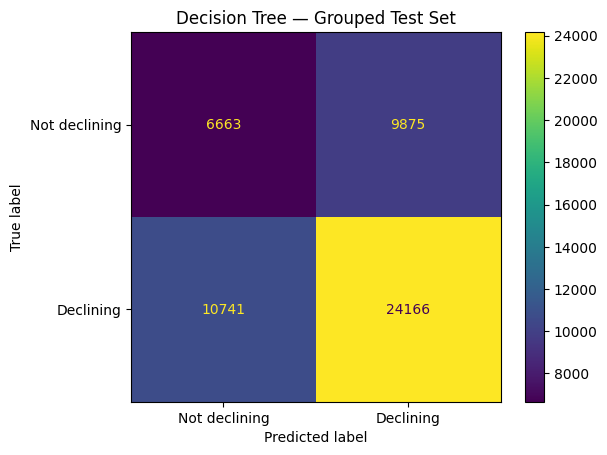

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, tree_pred)

print("Confusion matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not declining', 'Declining']
).plot()

plt.title("Decision Tree — Grouped Test Set")
plt.show()

In [17]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Decision Tree'],
    'Accuracy': [baseline_accuracy, tree_accuracy],
    'Precision': [baseline_precision, tree_precision],
    'Recall': [baseline_recall, tree_recall],
    'F1': [baseline_f1, tree_f1]
})

results

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.678530,0.678530,1.000000,0.808482
1,Decision Tree,0.599261,0.709909,0.692297,0.700992


In [18]:

signal_summary = model_data[
    [
        'imp_prev30',
        'visible_queries',
        'rare_share',
        'anon_share',
        'top_query_share'
    ]
].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])

signal_summary

,imp_prev30,visible_queries,rare_share,anon_share,top_query_share
count,102203.000000,102203.000000,102203.000000,102203.000000,102203.000000
mean,2454.496903,22.754684,0.124500,0.662515,0.392519
std,7214.444150,52.835191,0.118753,0.215594,0.257635
min,100.000000,1.000000,0.000000,0.000000,0.003126
25%,263.000000,4.000000,0.040548,0.550080,0.197450
50%,646.000000,9.000000,0.086294,0.713678,0.319018
75%,1982.000000,23.000000,0.168646,0.825863,0.520804
90%,5377.800000,53.000000,0.284160,0.894072,0.821238
95%,9827.900000,85.000000,0.372610,0.923143,1.000000
max,585502.000000,7889.000000,0.890710,0.996458,1.000000


In [20]:
p25_visible = model_data['visible_queries'].quantile(0.25)
p90_top_query = model_data['top_query_share'].quantile(0.90)
p90_rare = model_data['rare_share'].quantile(0.90)

ranking_data = model_data.copy()

ranking_data['reason_codes'] = ''

ranking_data.loc[
    ranking_data['is_declining'] == 1,
    'reason_codes'
] += 'OBSERVED_DECLINE;'

ranking_data.loc[
    ranking_data['visible_queries'] <= p25_visible,
    'reason_codes'
] += 'LOW_QUERY_VISIBILITY;'

ranking_data.loc[
    ranking_data['top_query_share'] >= p90_top_query,
    'reason_codes'
] += 'HIGH_QUERY_CONCENTRATION;'

ranking_data.loc[
    ranking_data['rare_share'] >= p90_rare,
    'reason_codes'
] += 'HIGH_RARE_QUERY_SHARE;'

ranking_data['reason_codes'] = (
    ranking_data['reason_codes']
    .str.rstrip(';')
)

print(f"P25 visible_queries: {p25_visible:.2f}")
print(f"P90 top_query_share: {p90_top_query:.3f}")
print(f"P90 rare_share: {p90_rare:.3f}")

ranking_data[['content_hash_id', 'reason_codes']].head(10)

P25 visible_queries: 4.00
P90 top_query_share: 0.821
P90 rare_share: 0.284


,content_hash_id,reason_codes
0,content_0dac238195631de4,
1,content_f6116743b00afc2d,OBSERVED_DECLINE;HIGH_QUERY_CONCENTRATION
2,content_332f337f995e9781,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY
3,content_82053c8b9d8a4811,OBSERVED_DECLINE
4,content_742939be32c206d2,
5,content_2df51e0cfad4523f,
6,content_60589b03dad153cb,
7,content_9b63d303fbfc07c6,HIGH_RARE_QUERY_SHARE
8,content_6a9399db4d7585e2,LOW_QUERY_VISIBILITY
9,content_b59c4b0b9e5eb85a,


In [21]:
def assign_action(row):
    reasons = row['reason_codes']

    if (
        'OBSERVED_DECLINE' in reasons
        or 'HIGH_QUERY_CONCENTRATION' in reasons
    ):
        return 'REVIEW'

    if 'LOW_QUERY_VISIBILITY' in reasons:
        return 'QUICK_WIN'

    if 'HIGH_RARE_QUERY_SHARE' in reasons:
        return 'MONITOR'

    return 'NO_ACTION'


ranking_data['recommended_action'] = ranking_data.apply(
    assign_action,
    axis=1
)

print(ranking_data['recommended_action'].value_counts())

ranking_data[
    [
        'content_hash_id',
        'recommended_action',
        'reason_codes'
    ]
].head(20)

recommended_action
REVIEW       67639
NO_ACTION    25758
QUICK_WIN     6162
MONITOR       2644
Name: count, dtype: int64


,content_hash_id,recommended_action,reason_codes
0,content_0dac238195631de4,NO_ACTION,
1,content_f6116743b00afc2d,REVIEW,OBSERVED_DECLINE;HIGH_QUERY_CONCENTRATION
2,content_332f337f995e9781,REVIEW,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY
3,content_82053c8b9d8a4811,REVIEW,OBSERVED_DECLINE
4,content_742939be32c206d2,NO_ACTION,
5,content_2df51e0cfad4523f,NO_ACTION,
6,content_60589b03dad153cb,NO_ACTION,
7,content_9b63d303fbfc07c6,MONITOR,HIGH_RARE_QUERY_SHARE
8,content_6a9399db4d7585e2,QUICK_WIN,LOW_QUERY_VISIBILITY
9,content_b59c4b0b9e5eb85a,NO_ACTION,


In [22]:
def calculate_signal_score(reason_codes):
    score = 0

    if 'OBSERVED_DECLINE' in reason_codes:
        score += 3

    if 'HIGH_QUERY_CONCENTRATION' in reason_codes:
        score += 2

    if 'LOW_QUERY_VISIBILITY' in reason_codes:
        score += 1

    if 'HIGH_RARE_QUERY_SHARE' in reason_codes:
        score += 1

    return score


ranking_data['signal_score'] = ranking_data['reason_codes'].apply(
    calculate_signal_score
)

action_priority = {
    'REVIEW': 1,
    'QUICK_WIN': 2,
    'MONITOR': 3,
    'NO_ACTION': 4
}

ranking_data['action_priority'] = ranking_data['recommended_action'].map(
    action_priority
)

ranked_queue = ranking_data.sort_values(
    ['action_priority', 'signal_score'],
    ascending=[True, False]
).copy()

ranked_queue[
    [
        'content_hash_id',
        'recommended_action',
        'signal_score',
        'reason_codes'
    ]
].head(20)

,content_hash_id,recommended_action,signal_score,reason_codes
237,content_e721bb9055b05126,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
294,content_309d7af237b2d9f2,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
389,content_a43190e015d31c58,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
420,content_4674899870e494fd,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
627,content_95b3878ff0afc277,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
830,content_c8c41d2b0d97ccec,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
969,content_992c01a4a3aceefe,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
1081,content_3a52e861e3917afa,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
1202,content_6d4498a86f19bf37,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
1401,content_c9aead7e899de3a9,REVIEW,7,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...


In [23]:
ranked_queue = ranking_data.sort_values(
    ['action_priority', 'signal_score', 'imp_prev30'],
    ascending=[True, False, False]
).copy()

ranked_queue['action_rank'] = range(1, len(ranked_queue) + 1)

ranked_queue[
    [
        'action_rank',
        'content_hash_id',
        'recommended_action',
        'signal_score',
        'imp_prev30',
        'reason_codes'
    ]
].head(20)

,action_rank,content_hash_id,recommended_action,signal_score,imp_prev30,reason_codes
33049,1,content_9361537862cd1883,REVIEW,7,5194.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
88907,2,content_9a874f110e6adc48,REVIEW,7,4843.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
33023,3,content_6d4e79343612ca25,REVIEW,7,4737.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
88590,4,content_9d5e9b986157f6c3,REVIEW,7,4718.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
33044,5,content_b0aea1c180b3e5c8,REVIEW,7,4710.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
88597,6,content_7fbecb1a1a0e9226,REVIEW,7,4685.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
88916,7,content_9ce6eea1dc1517d3,REVIEW,7,4685.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
33016,8,content_9918485f1d24807b,REVIEW,7,4675.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
88665,9,content_f3ca2e4b9d2a20cc,REVIEW,7,4671.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...
88843,10,content_8a760134198c8ebc,REVIEW,7,4667.0,OBSERVED_DECLINE;LOW_QUERY_VISIBILITY;HIGH_QUE...


### Recommended actions

The ranked queue is designed to support **human review and prioritization**, not to prescribe automatic content updates.

Each content item is assigned a recommended action based on observed signals:

- **REVIEW:** observed decline and/or high query concentration.
- **QUICK_WIN:** low query visibility without a higher-priority review signal.
- **MONITOR:** high rare-query share without higher-priority signals.
- **NO_ACTION:** no strong signal identified by the defined rules.

These recommendations are intended as **decision-support signals**. They do not establish causality, predict future search performance, or imply that a content item should necessarily be updated.

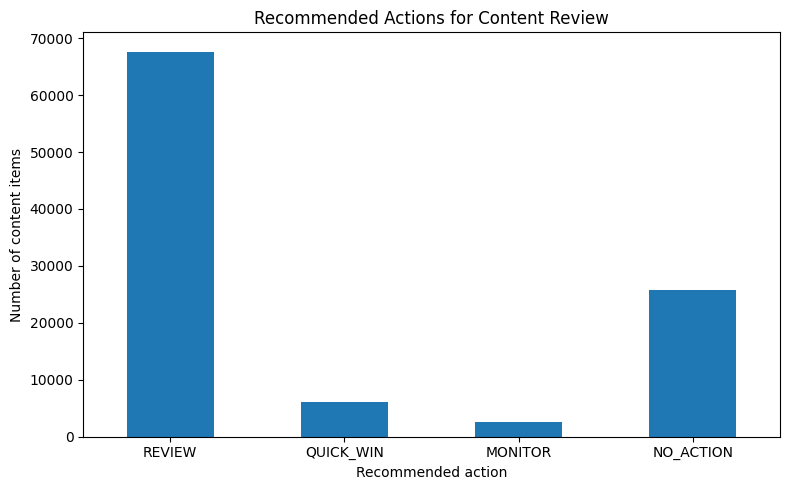

In [24]:
import matplotlib.pyplot as plt

action_counts = (
    ranked_queue['recommended_action']
    .value_counts()
    .reindex(['REVIEW', 'QUICK_WIN', 'MONITOR', 'NO_ACTION'])
)

plt.figure(figsize=(8, 5))
action_counts.plot(kind='bar')

plt.title('Recommended Actions for Content Review')
plt.xlabel('Recommended action')
plt.ylabel('Number of content items')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Decision Tree feature importance

The Decision Tree relied most on `visible_queries` and `rare_share`, followed by `anon_share` and `imp_prev30`. `top_query_share` contributed relatively little to the tree's splits.

These values describe the features used most by the fitted tree and should not be interpreted as causal effects or independent measures of predictive power. The grouped test results also showed that the Decision Tree did not outperform the majority-class baseline.

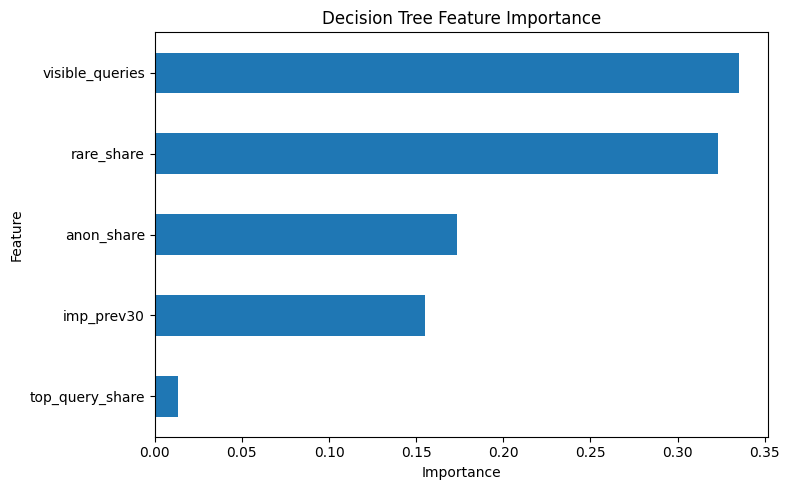

In [25]:
importance = (
    pd.Series(tree.feature_importances_, index=feature_cols)
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh')

plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

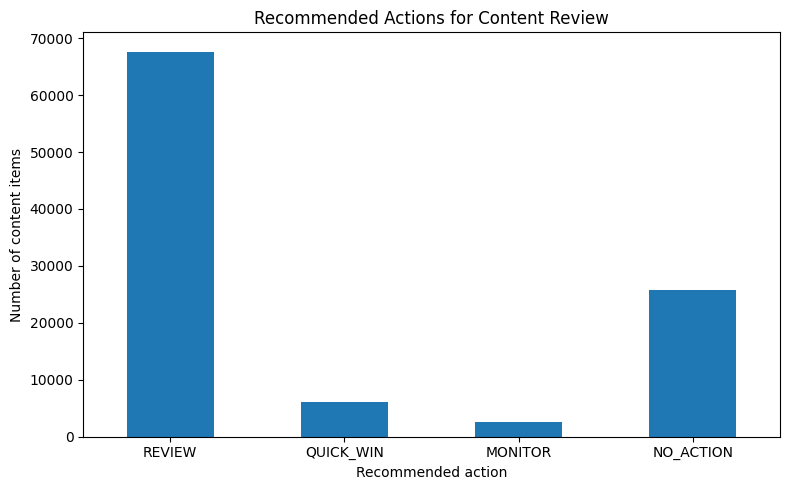

In [26]:
import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

action_counts = (
    ranked_queue['recommended_action']
    .value_counts()
    .reindex(['REVIEW', 'QUICK_WIN', 'MONITOR', 'NO_ACTION'])
)

plt.figure(figsize=(8, 5))
action_counts.plot(kind='bar')

plt.title('Recommended Actions for Content Review')
plt.xlabel('Recommended action')
plt.ylabel('Number of content items')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "work/figures/capstone_recommended_actions.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

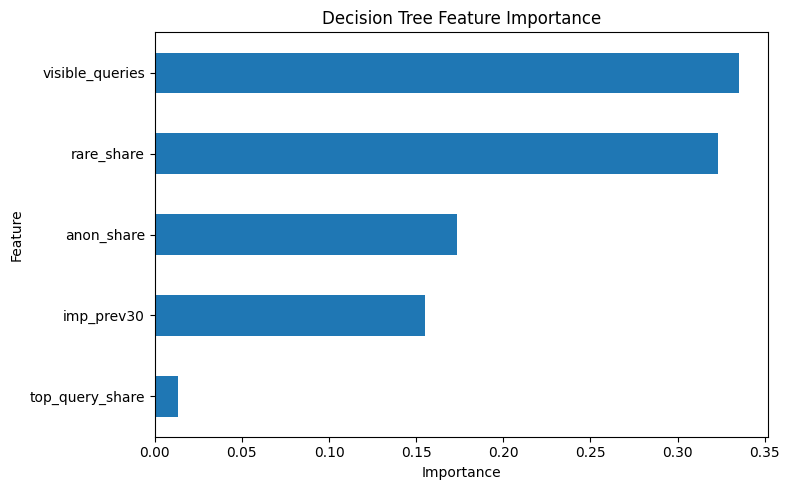

In [27]:
plt.figure(figsize=(8, 5))

importance = (
    pd.Series(tree.feature_importances_, index=feature_cols)
    .sort_values(ascending=True)
)

importance.plot(kind='barh')

plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()

plt.savefig(
    "work/figures/capstone_feature_importance.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [28]:
results

,Model,Accuracy,Precision,Recall,F1
0,Baseline,0.678530,0.678530,1.000000,0.808482
1,Decision Tree,0.599261,0.709909,0.692297,0.700992


In [29]:
import os

os.makedirs("work/outputs", exist_ok=True)

# 1. Model performance results
results_path = "work/outputs/capstone_model_results.csv"
results.to_csv(results_path, index=False)

# 2. Add observed impression change for the ranked queue
ranked_queue = ranked_queue.merge(
    data[
        ['content_hash_id', 'imp_last30']
    ],
    on='content_hash_id',
    how='left'
)

ranked_queue['impression_change_pct'] = (
    (ranked_queue['imp_last30'] - ranked_queue['imp_prev30'])
    / ranked_queue['imp_prev30']
) * 100

# 3. Final public-safe ranked queue
queue_export = ranked_queue[
    [
        'action_rank',
        'client_hash_id',
        'content_hash_id',
        'recommended_action',
        'reason_codes',
        'signal_score',
        'imp_prev30',
        'imp_last30',
        'impression_change_pct'
    ]
].copy()

queue_path = "work/outputs/capstone_ranked_action_queue.csv"
queue_export.to_csv(queue_path, index=False)

print("OUTPUTS CREATED")
print(f"- {results_path}")
print(f"- {queue_path}")
print(f"- Ranked queue rows: {len(queue_export):,}")

OUTPUTS CREATED
- work/outputs/capstone_model_results.csv
- work/outputs/capstone_ranked_action_queue.csv
- Ranked queue rows: 102,203


## Results

The grouped evaluation showed that the majority-class baseline outperformed the Decision Tree on the held-out client groups. The baseline achieved 0.679 accuracy and 0.808 F1, while the Decision Tree achieved 0.599 accuracy and 0.701 F1. The Decision Tree achieved higher precision (0.710 versus 0.679), but its recall was lower (0.692 versus 1.000).

Within the fitted Decision Tree, `visible_queries` and `rare_share` had the highest feature importance, followed by `anon_share` and `imp_prev30`. `top_query_share` contributed relatively little to the tree's splits.

For decision support, the analysis produced a ranked review queue of 102,203 content items. The queue contains 67,639 items classified as REVIEW, 6,162 as QUICK_WIN, 2,644 as MONITOR, and 25,758 as NO_ACTION. These categories are based on transparent signal rules derived from the observed data distribution.

## Limitations

The Decision Tree did not outperform the majority-class baseline under client-level grouped validation. The model also produced both false positives and false negatives, limiting its use as a reliable predictive classifier.

The observed decline label is defined from historical impression changes and should not be interpreted as a causal measure of content quality or future search performance. Feature importance indicates how the fitted tree used the available signals, not causal influence.

The ranked queue is therefore intended for human review and prioritization rather than automatic content updates. The recommendations do not establish causality, predict Google's ranking behavior, or demonstrate that refreshing a content item will improve future performance.